In [2]:
import duckdb
import matplotlib.pyplot as plt

con = duckdb.connect("../blood_data.duckdb")


In [3]:
import pandas as pd

# 1. Get the range of years
year_range = con.execute("""
    SELECT min(year(visit_date)), max(year(visit_date)) 
    FROM retention
""").fetchall()

start_year = year_range[0][0]
end_year = year_range[0][1]

# 2. Get the Total New Donors per year (The Denominator)
# We can use 'visit_status' = 'First Visit' or 'nth_visit' = 1
total_donors_query = con.execute("""
    SELECT year(visit_date) as year, count(distinct donor_id)
    FROM retention 
    WHERE visit_status = 'First Visit' -- Leveraging your new column
    GROUP BY year
""").fetchall()

total_new_donor = dict(total_donors_query)

# 3. Calculate Retention (The Numerator)
year_dict = {}
rate_retention = {}

for i in range(0, end_year - start_year + 1):
    parent_year = start_year + i
    
    # Skip if no new donors in this year (prevents div by zero)
    if parent_year not in total_new_donor or total_new_donor[parent_year] == 0:
        continue
        
    year_dict[parent_year] = {}
    rate_retention[parent_year] = {}
    
    # Inner loop: Check subsequent years
    for j in range(0, end_year - parent_year + 1):
        child_year = parent_year + j
        
        # SQL Logic:
        # Find count of donors who started in 'parent_year' 
        # AND exist in the table in 'child_year'
        # This is a Self-Join logic
        numerator = con.execute(f"""
            SELECT count(distinct t2.donor_id)
            FROM retention t1
            JOIN retention t2 ON t1.donor_id = t2.donor_id
            WHERE t1.visit_status = 'First Visit'
              AND year(t1.visit_date) = {parent_year} 
              AND year(t2.visit_date) = {child_year}
        """).fetchone()[0]
        
        year_dict[parent_year][child_year] = numerator
        
        # Calculate Percentage
        rate = (numerator / total_new_donor[parent_year]) * 100
        rate_retention[parent_year][child_year] = round(rate, 2)

# Display a snippet to verify
print("Retention Rates Calculated.")

Retention Rates Calculated.


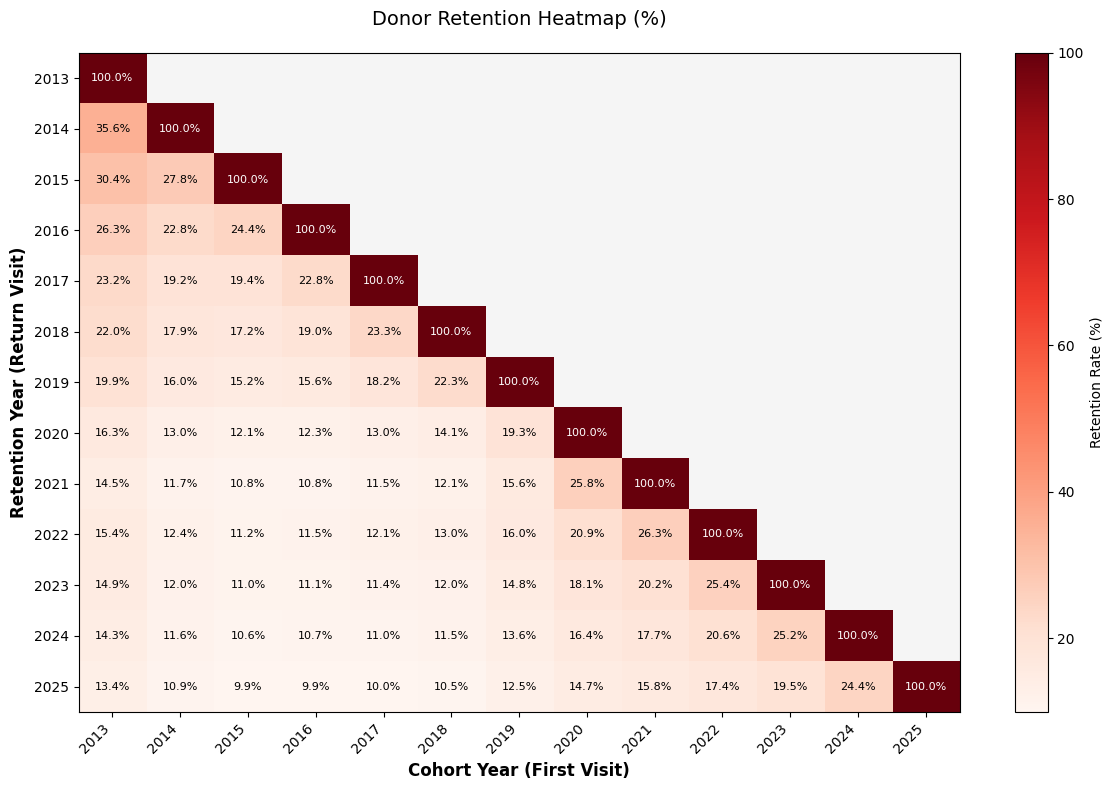

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = rate_retention 

# 1. Build DataFrame
rows = sorted(data.keys()) 
cols = sorted({child for inner in data.values() for child in inner.keys()})
mat = pd.DataFrame(index=rows, columns=cols, dtype=float)

for parent, children in data.items():
    for child, val in children.items():
        mat.loc[parent, child] = val

# 2. Prepare for Plotting
# Rows = Child Year (Y-axis), Cols = Parent Year (X-axis)
mat_for_plot = mat.T 

# Ensure correct sorting
mat_for_plot = mat_for_plot.sort_index(ascending=True) # Child years increasing down
mat_for_plot = mat_for_plot.sort_index(axis=1)         # Parent years increasing right

# 3. Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Mask invalid values (NaN) so they appear grey/white
masked = np.ma.masked_invalid(mat_for_plot.values)
cmap = plt.cm.Reds
cmap.set_bad(color='#f5f5f5') # Light grey for future/invalid years

im = ax.imshow(masked, aspect='auto', cmap=cmap, interpolation='nearest')

# We do NOT invert Y axis here usually, keeping earliest year at top is standard for Y-axis
# But based on your previous code, you inverted it. 
# Standard logic: Top row = Earliest Child Year. 
# If you want 2025 at the top, invert. If you want 2013 at the top, do not invert.
# ax.invert_yaxis() 

# 4. Labels and Ticks
ax.set_xticks(range(len(mat_for_plot.columns)))
ax.set_xticklabels(mat_for_plot.columns, rotation=45, ha='right')

ax.set_yticks(range(len(mat_for_plot.index)))
ax.set_yticklabels(mat_for_plot.index)

ax.set_xlabel('Cohort Year (First Visit)', fontsize=12, fontweight='bold')
ax.set_ylabel('Retention Year (Return Visit)', fontsize=12, fontweight='bold')
ax.set_title('Donor Retention Heatmap (%)', fontsize=14, pad=20)

# 5. Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Retention Rate (%)')

# 6. Text Annotations
# Threshold for text color (white text on dark red background)
threshold = masked.max() / 2 

for i in range(len(mat_for_plot.index)):
    for j in range(len(mat_for_plot.columns)):
        val = mat_for_plot.iat[i, j]
        if not pd.isna(val):
            # Styling logic: White text if cell is dark, black if cell is light
            text_color = 'white' if val > threshold else 'black'
            ax.text(j, i, f"{val:.1f}%", va='center', ha='center', 
                    fontsize=8, color=text_color)

plt.tight_layout()
plt.show()

In [5]:
con.close()